<a href="https://colab.research.google.com/github/arnavgupta27/Credit_Card_Fraud_Detector/blob/master/Practicum_6tm_sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Necessary packages**


In [ ]:
## Install all the necessary packages to run the code (ignore if already installed)
'''

'''
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install simple_colors
!pip install chardet
!pip install imblearn
!pip install imbalanced-learn
!pip install -U seaborn

# **Importing necessary libraries**


In [ ]:
## Importing all the necessary libraries

## To suppress warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
np.random.seed(0)   ## set random seed
import pandas as pd
import chardet
import os
import pickle
from collections import Counter

# For plots
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# sklearn packages (for pre-processing, model-building, evaluators, cross-validators, etc.)
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn import preprocessing
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn import linear_model
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, roc_auc_score, f1_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit

# Imblearn packages (for over_sampling and imblearn pipelines)
from imblearn import over_sampling
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline, make_pipeline  ## Using packages from imblearn.pipeline for making pipelines


## time and datetime
import datetime
import time

## for bold text
from simple_colors import *

## Pandas DataFrame display options
pd.set_option('display.max_columns', None)
pd.set_option("max_colwidth", None)
pd.set_option("display.max_rows", None)
pd.set_option('display.max_seq_items', None) #For printing a long-sequence

In [ ]:
##Defining a function to plot confusion matrix

def plot_confusion_matrix(cm):
    """
    This function prints and plots the confusion matrix.
    """
    classes=['Non-Fraudulent','Fraudulent']
    cmap=plt.cm.Blues
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes, rotation=90)
    thresh = cm.max() / 2.
    for i in range (cm.shape[0]):
        for j in range (cm.shape[1]):
            plt.text(j, i, cm[i, j],horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label', fontsize= 10)
    plt.xlabel('Predicted label', fontsize=10)


def print_model_metrics(y_test,y_pred):
    print(" Model Stats Scores Summary : ")
    cp = confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(5,5))
    plot_confusion_matrix(cp)
    plt.show()

In [ ]:
##Defining a function for coloring NaN and Non-NaN values (Useful for missing values treatment)
def color_style(value):
    """
    Takes a scalar and returns a string with
    the css property `'color: red'` for value
    greater than 5% NaNs, and green for safer values
    and black for anything otherwise.
    """
    if value>0:
        color= 'red'
    elif value==0:
        color='green'
    else:
        color='black'
    return 'color: %s' % color

    ## Defining a function for percentage of missing values dataframe: null_prcnt_df
def null_prcnt_df(input_data):
    df= input_data.copy()
    missing = pd.DataFrame(100*df.isnull().sum()/len(df.index))
    missing.rename(columns={0:'Null_Percentage'}, inplace=True)
    missing = pd.DataFrame(missing.Null_Percentage).sort_values(by='Null_Percentage',ascending=False).style.applymap(color_style)
    return missing

# **Exploartory Data Analysis**

In [ ]:
##Confirming the encoding of the 'creditcard.csv' (dataset) file
file_path = os.path.join('creditcard.csv')
raw_data = open(file_path, 'rb').readline()

encoding = chardet.detect(raw_data)
print("File encoding details:\n",encoding)

File encoding details:
 {'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [ ]:
## Read the dataset: 'creditcard.csv'
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


**Data Understanding and Cleaning**

In [ ]:
df.shape


(284807, 31)

In [ ]:
df= df.rename(columns=lambda x: x.strip())   ##Removing whitespaces in column names (if any)
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Observations:**<br>(i) The `features (V1, V2, V3, up to V28)` are the `principal components` *(numerical input components)* obtained using `PCA`.<br>
(ii) The `feature 'Time'` *contains the seconds* elapsed between the first transaction in the data set and the subsequent transactions.<br>
(iii) The `feature 'Amount'` is the *transaction amount*.<br>
(iv) The `feature 'Class'` represents *class labelling*. (0: Normal Transactions, 1: Fraud Transactions)<br>

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
## Checking percentage of missing values in the dataset
null_prcnt_df(df)

,Null_Percentage
Time,0.000000
V1,0.000000
V2,0.000000
V3,0.000000
V4,0.000000
V5,0.000000
V6,0.000000
V7,0.000000
V8,0.000000
V9,0.000000


**Observation:** No missing values found in the feature columns and output class.

In [ ]:
## Observing distribution of classes (0: Normal Transactions, 1: Fraud Transactions)

classes=df['Class'].value_counts()
normal_share=classes[0]/df['Class'].count()*100
fraud_share=classes[1]/df['Class'].count()*100

pattern_line= "*"*80
print(f"{pattern_line}\n{pattern_line}\n"+ \
      black("Distribution of Classes: (0: Normal Transactions, 1: Fraud Transactions)\n",'bold')+ \
      f"{classes}\n\n{pattern_line}")

print(black(f"Percentage of Normal Share i.e. Non-Fraudulent Transactions(%):\n",'bold')+ \
      f"{round(normal_share,4)} %"+ f"\n\n{pattern_line}")

print(black(f"Percentage of Fraud Share i.e. Fraudulent Transactions(%):\n",'bold')+ \
      f"{round(fraud_share,4)} %"+ f"\n\n{pattern_line}")

********************************************************************************
********************************************************************************
Distribution of Classes: (0: Normal Transactions, 1: Fraud Transactions)
Class
0    284315
1       492
Name: count, dtype: int64

********************************************************************************
Percentage of Normal Share i.e. Non-Fraudulent Transactions(%):
99.8273 %

********************************************************************************
Percentage of Fraud Share i.e. Fraudulent Transactions(%):
0.1727 %

********************************************************************************


**Univariate And Bivariate Analysis**

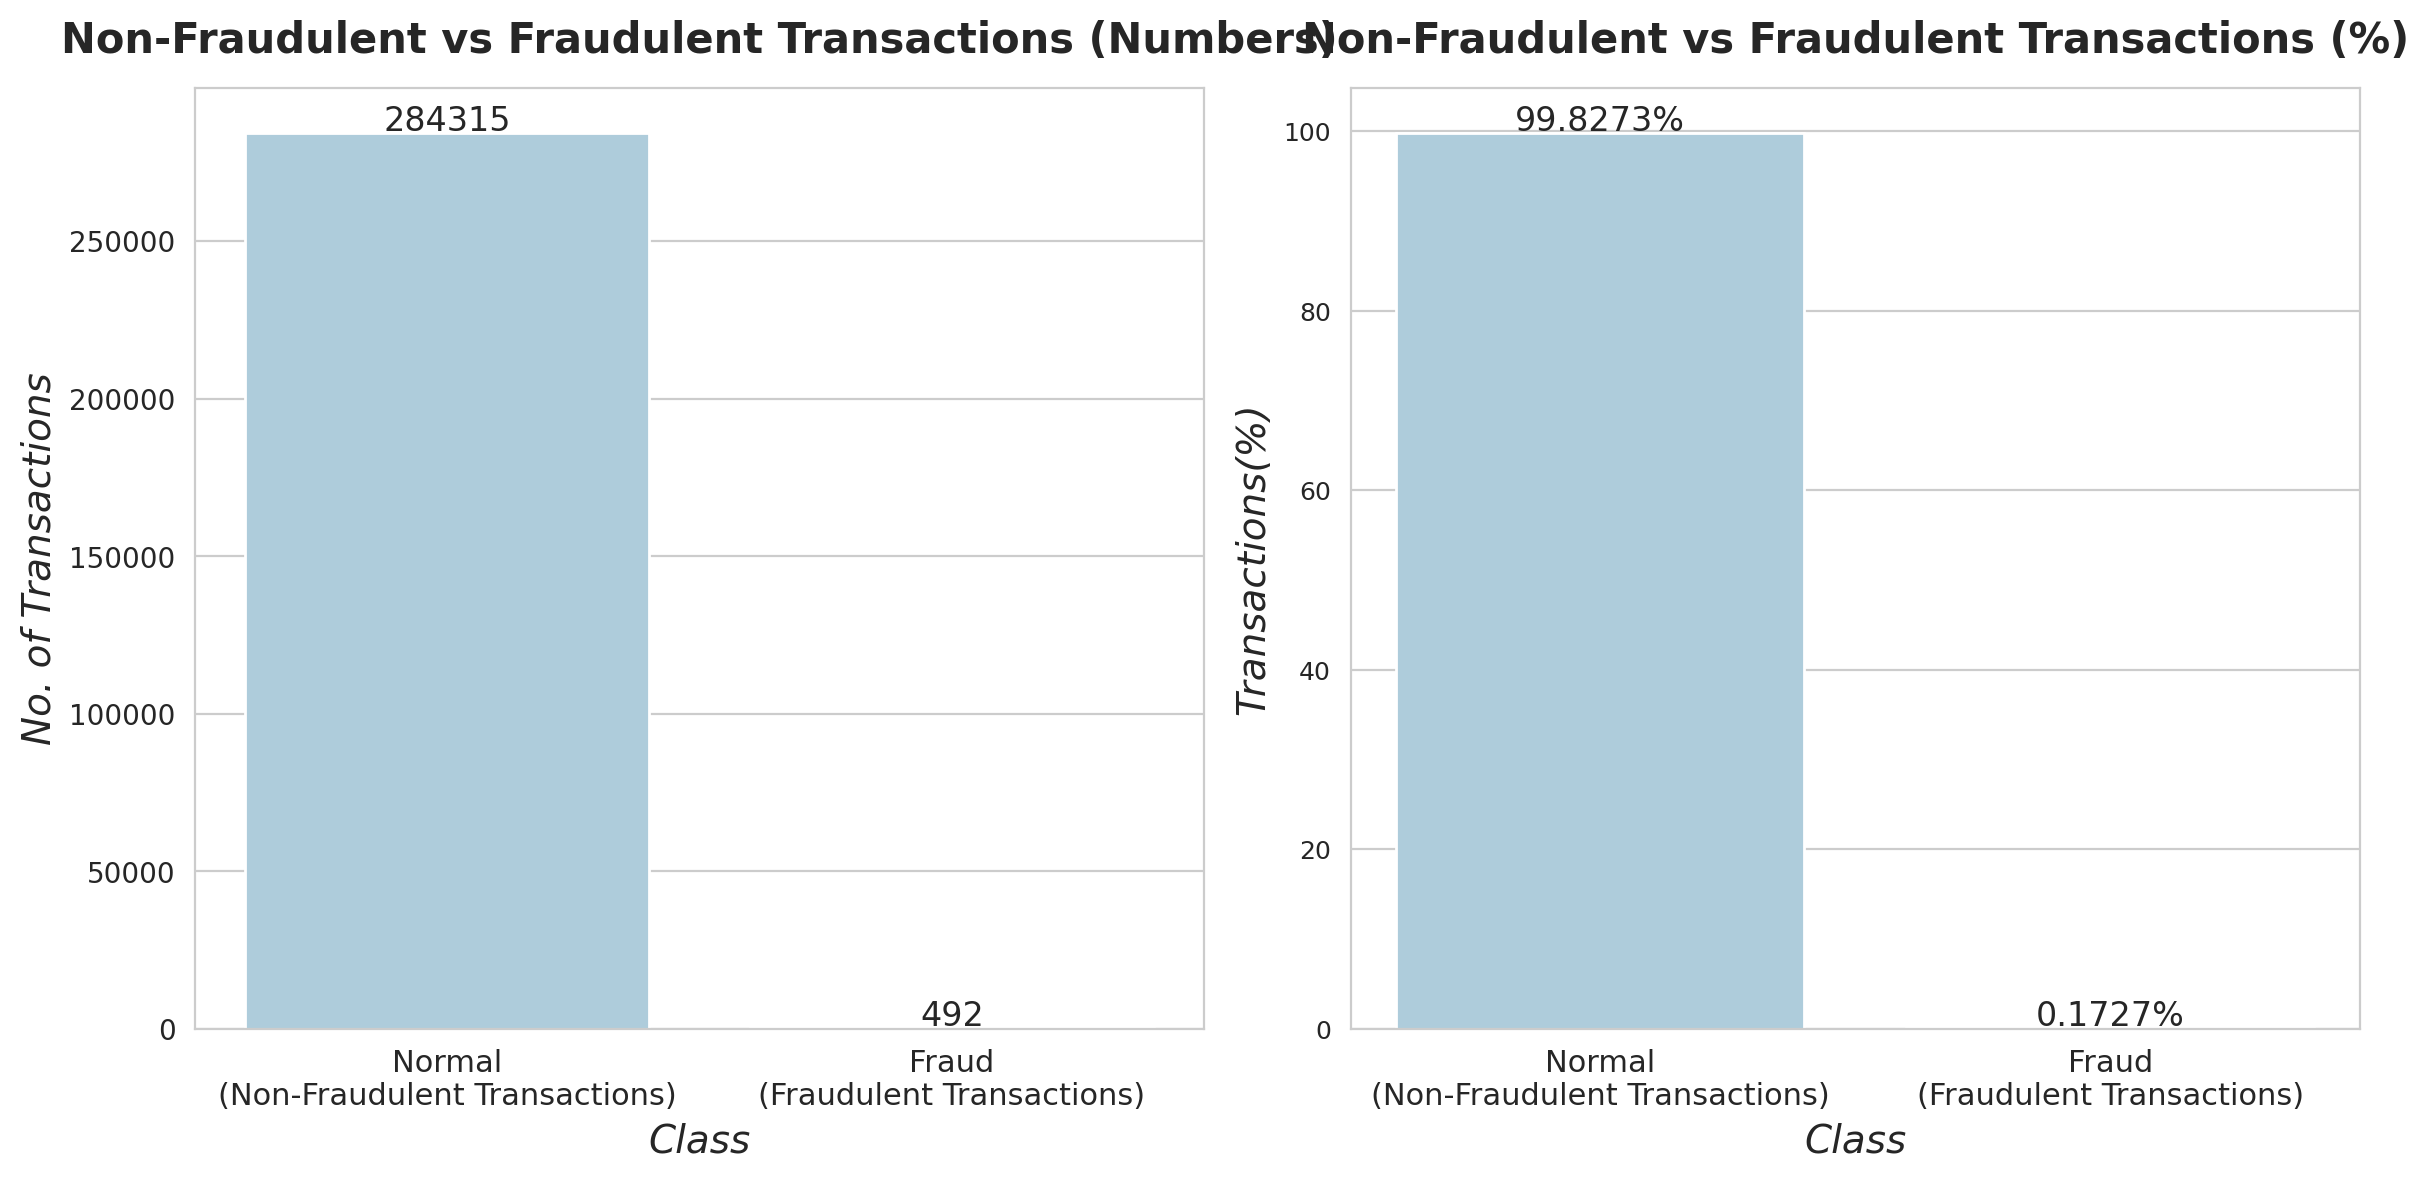

In [ ]:


## Creating a dataframe containing number and percentage of classes
class_data= [["Normal (Non-Fraudulent)", classes[0], normal_share],\
             ["Fraud (Fraudulent)", classes[1], fraud_share]]
df_class= pd.DataFrame(class_data, columns=["Class", "num_transactions", "prcnt_transactions"])


plt.figure(figsize=(12,6), dpi=200)
sns.set_style("whitegrid")


##Subplot_121 (Barplot for Number of non-fraudulent transactions vs fraudulent transactions)
plt.subplot(1,2,1)
ax_1= sns.barplot(data = df_class,x= "Class", y="num_transactions", palette=("Paired"))
ax_1.set_xticklabels(labels=['Normal\n(Non-Fraudulent Transactions)','Fraud\n(Fraudulent Transactions)'], fontsize=11)
plt.title("Non-Fraudulent vs Fraudulent Transactions (Numbers)", fontsize=15, fontweight='bold', y=1.02)
plt.ylabel("No. of Transactions", fontsize=14, fontstyle='italic')
plt.xlabel("Class", fontsize=14, fontstyle='italic')
plt.yticks(fontsize=10)

for i in ax_1.patches:
    ax_1.annotate("{0:.0f}".format(i.get_height()), (i.get_x() + i.get_width() / 2.\
                                                 , i.get_height()), ha = 'center'\
        , va = 'top' , xytext = (0, 10), textcoords = 'offset points',rotation=0, fontsize=12)


##Subplot_122 (Barplot for Percentage of non-fraudulent transactions vs fraudulent transactions)
plt.subplot(1,2,2)
ax_2= sns.barplot(data = df_class,x= "Class", y="prcnt_transactions", palette=("Paired"))
ax_2.set_xticklabels(labels=['Normal\n(Non-Fraudulent Transactions)','Fraud\n(Fraudulent Transactions)'], fontsize=11)
plt.title("Non-Fraudulent vs Fraudulent Transactions (%)", fontsize=15, fontweight='bold', y=1.02)
plt.ylabel("Transactions(%)", fontsize=14, fontstyle='italic')
plt.xlabel("Class", fontsize=14, fontstyle='italic')
plt.yticks(fontsize=9)

for j in ax_2.patches:
    ax_2.annotate("{0:.4f}".format(j.get_height())+"%", (j.get_x() + j.get_width() / 2.\
                                                 , j.get_height()), ha = 'center'\
        , va = 'top' , xytext = (0, 10), textcoords = 'offset points',rotation=0, fontsize=12)

plt.tight_layout()
plt.autoscale()
plt.show()

**Observation:**<br>Out of a `total of 2,84,807 transactions`, `492 were fraudulent`. This data set is highly unbalanced, with the positive class (`frauds`) accounting for `approximately 0.172%` of the total transactions.


In [ ]:
## Let's define a function for scatter plot
def scatter_plot(my_figsize, title, my_data, x, y, x_unit):
    fig = plt.figure(figsize= my_figsize)
    cmap = sns.color_palette('Set1')

    df= my_data.copy()
    plt.figure(figsize=(10,5), dpi=100)
    sns.set_style("whitegrid")
    sns.scatterplot(x= x, y= y, data=df)
    plt.title((f"{title}"), fontweight='bold', fontsize=15, y=1.02)
    plt.xlabel(x+f" {x_unit}", fontsize=13, fontstyle='italic')
    plt.ylabel(y, fontsize=13, fontstyle='italic')

    plt.grid(True)
    plt.autoscale()
    plt.tight_layout()
    plt.show()

<Figure size 1200x1400 with 0 Axes>

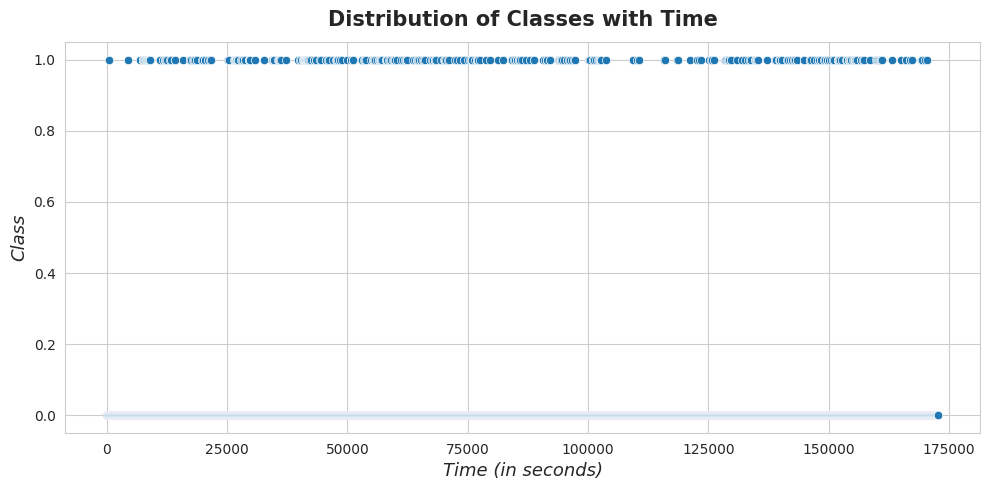

In [ ]:
# Create a scatter plot to observe the distribution of classes with Time
scatter_plot(my_figsize=(12,14), title= "Distribution of Classes with Time", my_data=df,\
             x="Time", x_unit="(in seconds)", y="Class")

**Observation:** <br>Clearly we see the distinction in the number of fraud cases (Class Label:1) with respect to normal cases (Class Label: 0) where the latter being extremely high in number in comparison to the former class.

<Figure size 1200x1400 with 0 Axes>

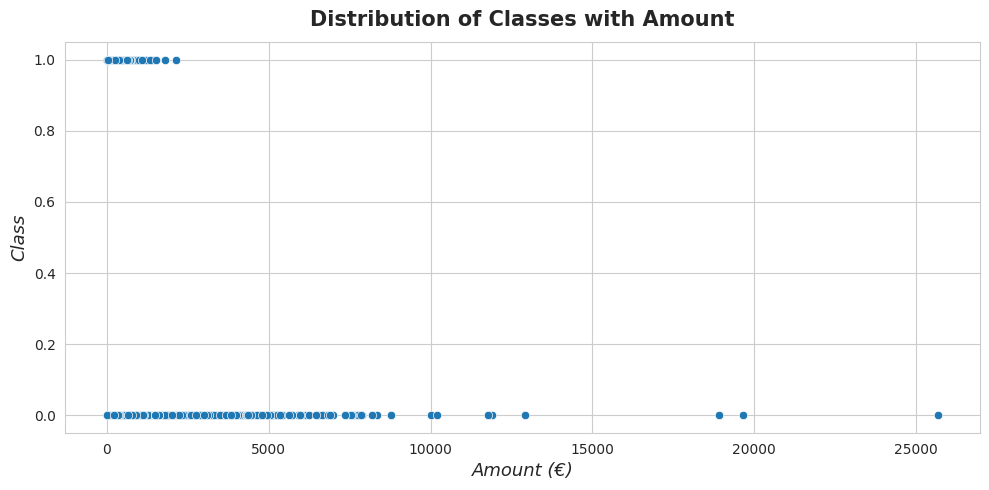

In [ ]:
# Create a scatter plot to observe the distribution of classes with Amount
scatter_plot(my_figsize=(12,14), title= "Distribution of Classes with Amount", my_data=df,\
             x="Amount", x_unit="(€)", y="Class")

In [ ]:
## Let's find the maximum transaction amount in Fraud Cases (Class Label: 1).
max_trnsctn_fraud= df[df.Class==1]["Amount"].max()
print(f"Maximum fraud transaction amount: €{max_trnsctn_fraud}")

Maximum fraud transaction amount: €2125.87


In [ ]:
## Statistical summary of 'Amount' feature for different classes
summary_class_0= df[df.Class==0].Amount.describe([0.1,0.25,0.5,0.75,0.9,0.95,0.99,1])
print(black(f"Statistical summary of 'Amount' feature (Normal Transactions):\n\n",'bold'),summary_class_0)

summary_class_1= df[df.Class==1].Amount.describe([0.1,0.25,0.5,0.75,0.9,0.95,0.99,1])
print(black(f"\nStatistical summary of 'Amount' feature (Fraud Transactions):\n\n",'bold'),summary_class_1)

Statistical summary of 'Amount' feature (Normal Transactions):

 count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
10%           1.000000
25%           5.650000
50%          22.000000
75%          77.050000
90%         202.724000
95%         364.409000
99%        1016.966400
100%      25691.160000
max       25691.160000
Name: Amount, dtype: float64

Statistical summary of 'Amount' feature (Fraud Transactions):

 count     492.000000
mean      122.211321
std       256.683288
min         0.000000
10%         0.760000
25%         1.000000
50%         9.250000
75%       105.890000
90%       346.746000
95%       640.905000
99%      1357.427900
100%     2125.870000
max      2125.870000
Name: Amount, dtype: float64


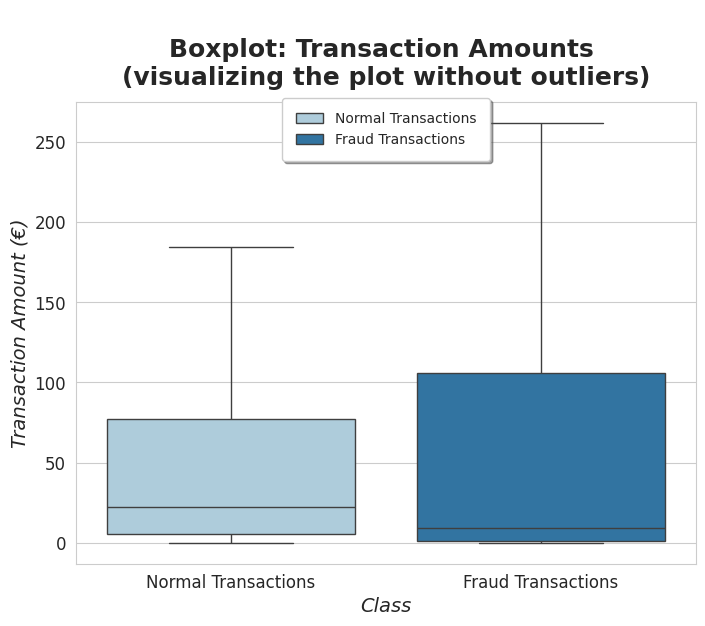

In [ ]:
## Visualising the statistics of transaction amounts
plt.figure(figsize=(8,6), dpi=100)
sns.set_style("whitegrid")

 ## Note: Set (showflier=False) to eliminate the effect of outliers in the transaction amounts
ax_31= sns.boxplot(data=df, y="Amount", x="Class", hue="Class",showfliers=False, palette=("Paired"))
ax_31.set_xticklabels(labels=['Normal Transactions','Fraud Transactions'], fontsize=12)
plt.title(f"\nBoxplot: Transaction Amounts \n(visualizing the plot without outliers)", fontsize=18, fontweight='bold', y=1.02)
plt.ylabel("Transaction Amount (€)", fontsize=14, fontstyle='italic')
plt.xlabel("Class", fontsize=14, fontstyle='italic')
plt.yticks(fontsize=12)

#legend
L31= ax_31.legend(loc='center', bbox_to_anchor=(0.5, 0.94), fancybox=True, framealpha=1, shadow=True, borderpad=1)
L31.get_texts()[0].set_text('Normal Transactions')
L31.get_texts()[1].set_text('Fraud Transactions')

plt.show()

**Observations:**
<br>(i) From the plot of distribution of classes with respect to transaction amount, it is quite evident that the `transaction amounts for fraud cases were lesser than approximately €2200`.
<br>(ii) Precisely, `average fraud transaction amount is approximately €122` (from statistical summary) and `maximum fraud transaction amount is €2125.87`.
<br>(iii) `Normal transactions have a wide-range of amounts with certain outliers` (as seen from the plot of Distribution of Class with Amount).

**Analyzing the `Time` variable before we come to any conclusion.**

In [ ]:
df.Time.head()

,Time
0,0.0
1,0.0
2,1.0
3,1.0
4,2.0


In [ ]:
df.Time.tail()

,Time
284802,172786.0
284803,172787.0
284804,172788.0
284805,172788.0
284806,172792.0


In [ ]:
## Using pandas 'to_timedelta' to convert pandas Series from a recognized timedelta format / value into a Timedelta type
Time_Delta= pd.to_timedelta(df.Time, unit='s')
Time_Delta.head()

,Time
0,0 days 00:00:00
1,0 days 00:00:00
2,0 days 00:00:01
3,0 days 00:00:01
4,0 days 00:00:02


In [ ]:
Time_Delta.tail()



,Time
284802,1 days 23:59:46
284803,1 days 23:59:47
284804,1 days 23:59:48
284805,1 days 23:59:48
284806,1 days 23:59:52


In [ ]:
## DERIVING NEW TIME FEATURES FOR ANALYSIS
## Extracting the number of days, hours and minutes from 'Time_Delta' variable.
df['Time_Days']= (Time_Delta.dt.components.days).astype(int) ## Number of days
df['Time_Hours']= (Time_Delta.dt.components.hours).astype(int) ## Number of hours
df['Time_Minutes']= (Time_Delta.dt.components.minutes).astype(int) ## Number of minutes

df[['Time', 'Time_Days', 'Time_Hours', 'Time_Minutes']].tail()  ##Checking the tail for verifying successful operations

,Time,Time_Days,Time_Hours,Time_Minutes
284802,172786.0,1,23,59
284803,172787.0,1,23,59
284804,172788.0,1,23,59
284805,172788.0,1,23,59
284806,172792.0,1,23,59


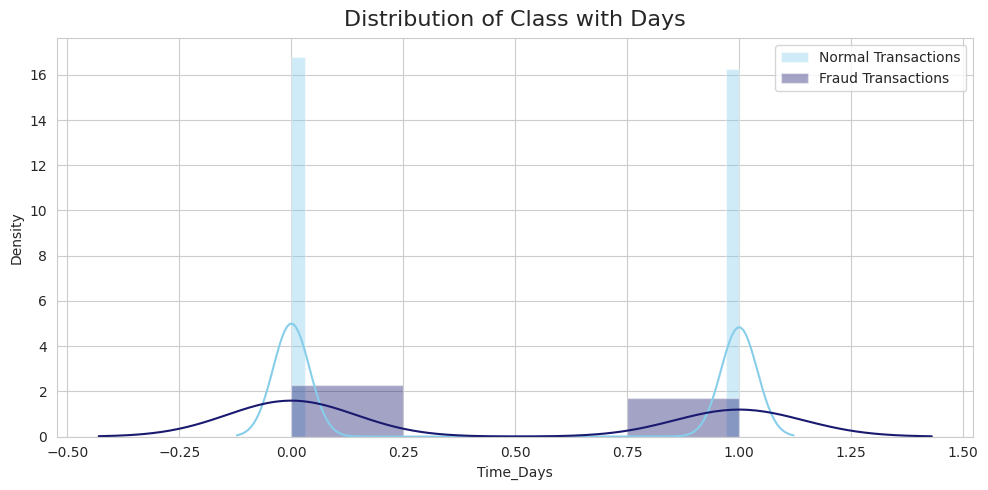

In [ ]:
## Analyzing distribution of classes with days

plt.figure(figsize=(10,5), dpi=100)

sns.distplot(df[df.Class == 0]["Time_Days"], label= "Normal Transactions", color='skyblue')
sns.distplot(df[df.Class == 1]["Time_Days"], label= "Fraud Transactions", color= 'midnightblue')

plt.title('Distribution of Class with Days', fontsize=16, y=1.01)
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** <br>`Time_Days` feature `doesn't offer much insights as we only have the records for day 0 and day 1` respectively.

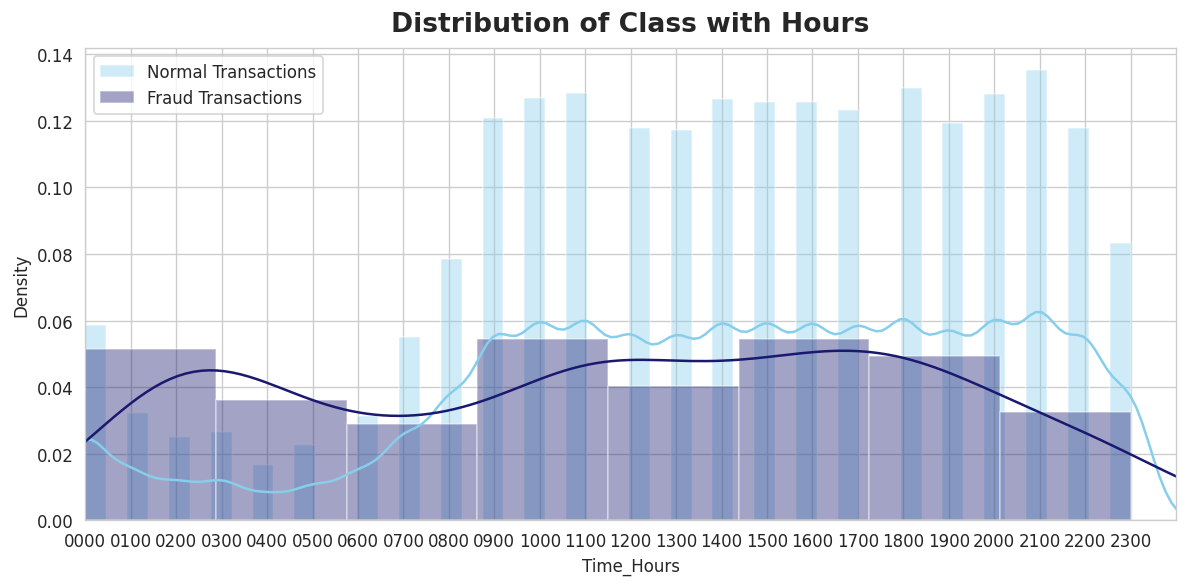

In [ ]:
## Analyzing distribution of classes with hours

fig= plt.figure(figsize=(10,5), dpi=120)
ax_4= fig.add_subplot(1,1,1)
sns.set_style("whitegrid")

ax_4= sns.distplot(df[df.Class == 0]["Time_Hours"], label= "Normal Transactions", color='skyblue')  # Distplot for normal transactions
ax_4= sns.distplot(df[df.Class == 1]["Time_Hours"], label= "Fraud Transactions", color= 'midnightblue')  #Distplot for fraud transactions

ax_4.set_title('Distribution of Class with Hours', fontsize=16, fontweight='bold', pad=10)
plt.xlim(0,24)                          ## Limitng the x-axis to number of hours in a day
ax_4.set_xticks(np.arange(0,24))

## List Labels
list_a= ['0'+str(i) for i in list(np.arange(0,10))]
list_b= [str(i) for i in list(np.arange(10,24))]
list_a.extend(list_b)
list_hours= [str(j)+"00" for j in list_a]
ax_4.set_xticklabels(list_hours)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Checking the hour at which most frauds occur
num_fraud_hrs= df[df.Class==1]['Time_Hours'].value_counts()
num_fraud_hrs

,count
Time_Hours,
2,57
11,53
18,33
17,29
15,26
4,23
7,23
14,23
16,22


In [ ]:
## Check total number of hours (must round to 24)
len(num_fraud_hrs)

24

**Observations:**<br>(i) `No distinct fixed pattern (w.r.t. fraud transactions) can be seen from the hours.`<br>(ii) From the distribution plot of normal transactions we can infer that `most number of normal transactions took place from 0800 hours till midnight (0000 hours)`. <br>
(iii) `Normal transactions are less in number during night-time` (from midnight (i.e. 00 hours) till 0800 hours).<br>
(iv) `Most number of Fraud Transactions took place at 0200 (no. of txns= 57), 1100 (no. of txns= 53) and 1800 (no. of txns= 33) hours respectively.` `No Fraud Transactions` occurred early morning `at 0600 hours`.<br>


As this is `not a time-series problem` and `no further insights` can be `derived from the 'Time' feature and associated derived time features`, we can `drop all the time variables-> "Time","Time_Days", "Time_Hours" and "Time_Minutes" feature columns`.

In [ ]:
# Drop unnecessary columns
drop_columns= ["Time","Time_Days","Time_Hours", "Time_Minutes"]  # (all time variables - original and derived ones)
df.drop(drop_columns, axis=1, inplace= True)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Splitting The Data into Train and Test**

In [ ]:
## Create X and y dataset for independent and dependent data
y= df['Class']        #Class variable
X= df.drop("Class", axis=1)

In [ ]:
## Splitting the data into train and test data  (80:20)

## Create a STRATIFIED train-test (Hence, passing the argument 'stratify= y')
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.20, stratify= y)

In [ ]:
## Checking class distribution in stratified train-test split
print(black("In y dataset:",'bold'), Counter(y))
print(black("\nIn y_train set:",'bold'), Counter(y_train))
print(black("\nIn y_test set:",'bold'), Counter(y_test))

In y dataset: Counter({0: 284315, 1: 492})

In y_train set: Counter({0: 227451, 1: 394})

In y_test set: Counter({0: 56864, 1: 98})


**Observation:** We have successfully **split the imbalanced dataset in the train-test split ratio (80:20) using stratified train-test-split**.

In [ ]:
# Considering train_test_split ratio (80:20)

print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

492
394
98


### <font>Plotting the distribution of variables (visualization)

**(Check skewness in the TRAIN data) - Examining the distribution of all the input feature variables**

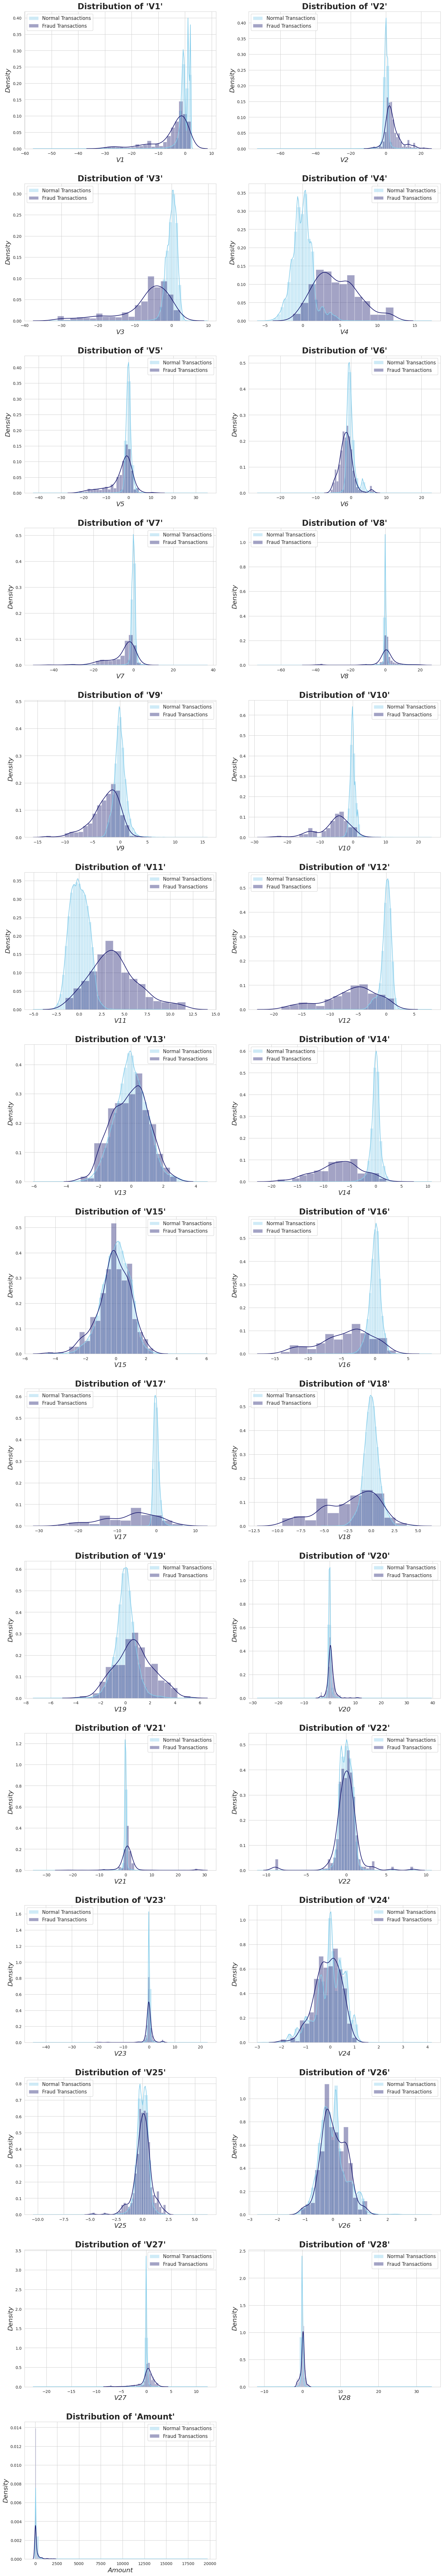

In [ ]:
# Plotting histograms to check the distribution of variables (in train data) for skewness

# Define a function for the plot
def plot_histograms_distribution_of_variables(check_data):
    input_feature_list= list(X.columns)       # list of input feature variables (analyzing entire dataset)

    f1, ax_skew1 = plt.subplots(15,2, figsize=(16,90))
    f1.delaxes(ax_skew1[14,1])    ## Passing indices of axes--This line will delete the last axis (used for odd-subplots)

    for index, feature in enumerate(input_feature_list):
        plt.subplot(15,2,index+1)
        sns.distplot(check_data[feature][df.Class == 0], label= "Normal Transactions", color='skyblue')       ## Distplot for feature density in Normal Transactions
        sns.distplot(check_data[feature][df.Class == 1], label= "Fraud Transactions", color= 'midnightblue')  ## Distplot for feature density in Fraud Transactions
        plt.title(f"Distribution of '{feature}'", fontsize= 20, fontweight='bold')
        plt.xlabel(feature, fontsize=16, fontstyle= 'italic')
        plt.ylabel("Density", fontsize=16, fontstyle= 'italic')
        plt.tight_layout(pad=3.0)   ##Increase spacing between subplots
        plt.legend(fontsize= 12)
    plt.show()

# Plotting histograms to check the distribution of variables (in train dataset) for skewness
plot_histograms_distribution_of_variables(X_train)

**Observation:** From the above graphs, `it is evident that skewness exists in the distribution of many variables within the train data. Also, we need to center the 'Amount' feature variable around mean 0.` Similarly, `we can expect to see  skewness in the test data`.

***As we know there is SKEWness , we will use power transformer to make it more gaussian***

### <font color=red>Skewness Mitigation:</font>

In [ ]:
# - Apply : preprocessing.PowerTransformer(copy=False) to fit & transform the train data & transform the test data

## For X dataset (train and test)
pt = PowerTransformer(copy=False)                  ## Instantiate an object of PowerTransformer() class
X_train_pt= pt.fit_transform(X_train)              ## fit_transform train set
X_test_pt = pt.transform(X_test)                   ## Transform only: test set

In [ ]:
## Create a dataframes for PowerTransformed 'X_train' and 'X_test' respectively (to be used later)
X_train_pt_df= pd.DataFrame(data= X_train_pt, columns= list(X.columns))
X_test_pt_df= pd.DataFrame(data= X_test_pt, columns= list(X.columns))

#### <font> Rechecking and Visualizing (Plotting) after using PowerTransformer.

Train data

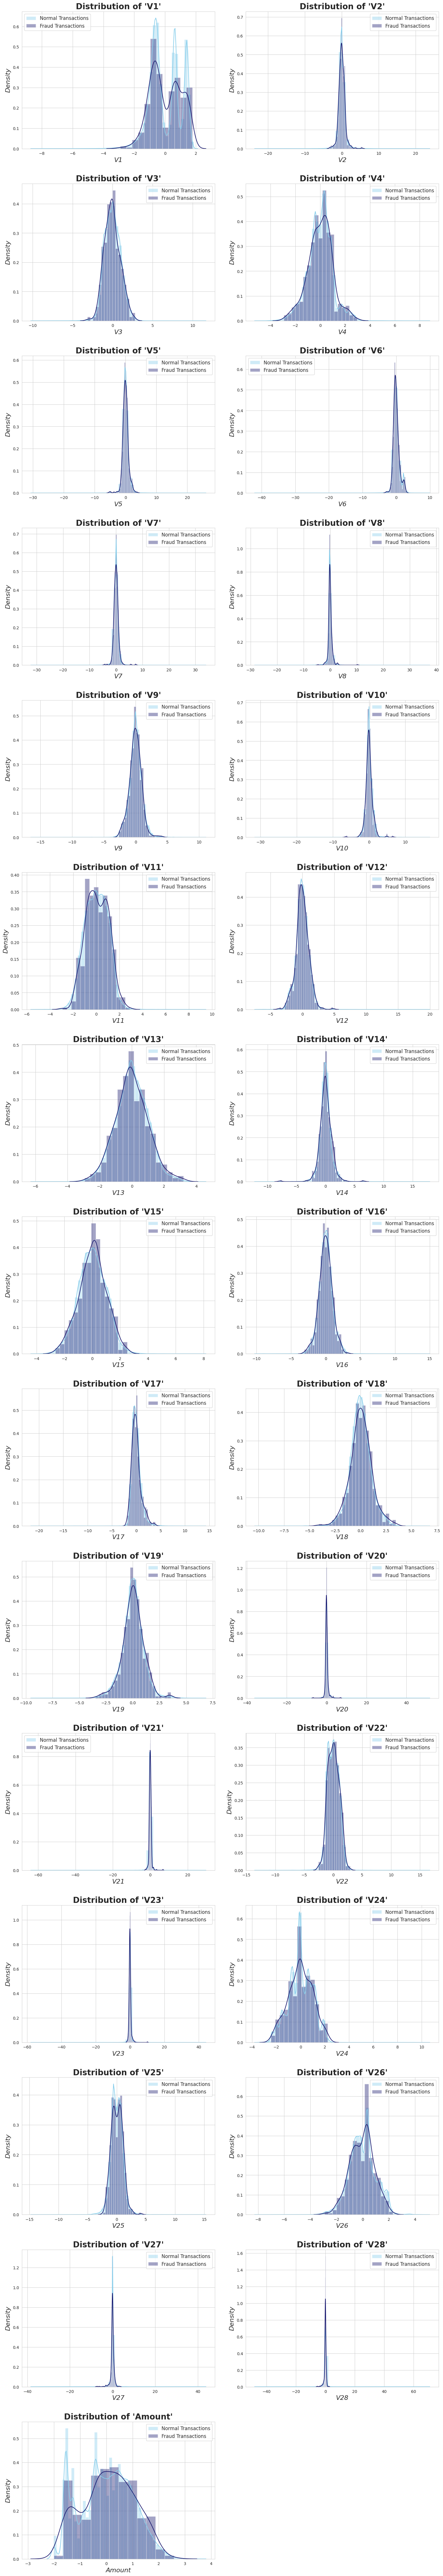

In [ ]:
# Plotting histograms to check the distribution of variables (in power transformed 'X_train_pt_df' set) for skewness
plot_histograms_distribution_of_variables(X_train_pt_df)

**Observation:** The `distribution of variables from the TRAIN dataset` is now `more gaussian in nature` and all feature variables are `centered about mean 0.` Thus, `skewness in the distribution of variables in the TRAIN dataset is mitigated successfully`.

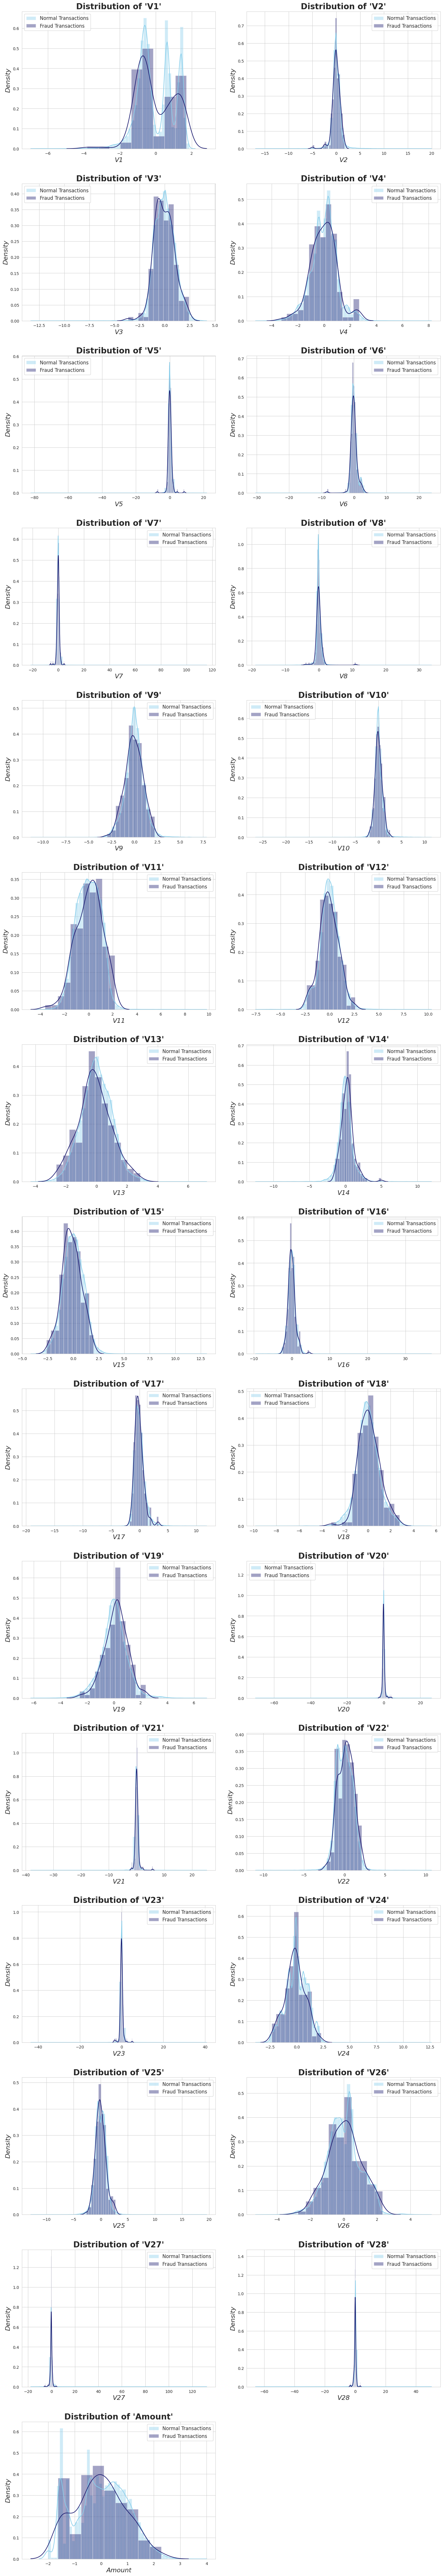

In [ ]:
# Plotting histograms to check the distribution of variables (in power transformed 'X_test_pt_df' set) for skewness
plot_histograms_distribution_of_variables(X_test_pt_df)

**Observation:** The `distribution of variables from the TEST dataset` is now `more gaussian in nature` and and all feature variables are `centered about mean 0.` Thus, `skewness in the distribution of variables in the TEST dataset is mitigated successfully`.

# **Model Building**

In [ ]:
#Create a pandas dataframe to store model results
results_df = pd.DataFrame(columns=['Data Handling Technique','Model', 'ROC_AUC_cv', 'ROC_AUC_test', 'Threshold', 'Precision','Recall','F1 score'])

In [ ]:
## Define a function to plot ROC_AUC curve
def plot_roc_auc_curve(fpr, tpr, roc_auc):
    print(f"ROC for test dataset {round(roc_auc*100,3)}%")
    plt.figure(figsize=(5,5))
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.plot(fpr,tpr,'b',label="Test ROC_AUC="+str(round(roc_auc,3)))
    plt.plot([0,1],[0,1],'r--')
    plt.ylabel('True Positive Rate (TPR)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.legend(loc='lower right')
    plt.show()

In [ ]:
## Function for printing the cross-validation results:
def best_cross_val_results(clf,data_handling_technique, model_name):
    print(black(f"\nData Handling Technique: {data_handling_technique}\nModel Name: {model_name}",'bold'))
    print(black("\n\nEvaluation results from cross-validation and optimal hyperparameters",'bold'))
    # Best Model and optimal hyperparameters
    print("Best Estimator:\n", clf.best_estimator_._final_estimator)
    print("Best ROC_AUC (mean cross-validated score):", clf.best_score_)
    print("Best (Optimal) Parameters:", clf.best_params_)

In [ ]:
# Function for prediction and evaluation results on test data:
def prediction_evaluation_results(clf,X_train,y_train,X_test,y_test, data_handling_technique,model_name,results_df):
    print(black("\nPrediction and Evaluation results: On Actual TEST SET",'bold'))
    y_pred= clf.predict(X_test)                                             # Find predicted values
    y_pred_probs = clf.predict_proba(X_test)[:,1]                           # Find predicted probabilities
    precision = metrics.precision_score(y_pred=y_pred, y_true=y_test)           # Precision and Recall Scores
    recall= metrics.recall_score(y_pred=y_pred, y_true=y_test)
    f1_score= metrics.f1_score(y_pred=y_pred, y_true=y_test)                    # f1_score
    test_roc_auc = metrics.roc_auc_score(y_score= y_pred_probs, y_true=y_test)  # Test ROC_AUC
    print(f"\nTest ROC_AUC: {test_roc_auc}")
    test_accuracy = metrics.accuracy_score(y_pred=y_pred, y_true=y_test)        # test accuracy
    print(f"Test Accuracy: {test_accuracy}");print()
    print("Confusion Matrix")                                                   # print confusion matrix
    print_model_metrics(y_test, y_pred)
    print("Classification Report")                                              # Print classification report
    print(classification_report(y_test, y_pred))
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_probs)              # fpr, tpr and threshold
    threshold= thresholds[np.argmax(tpr-fpr)]                                   # Find the optimal threshold value
    print("Optimal Threshold:", threshold)
    plot_roc_auc_curve(fpr, tpr, test_roc_auc)                                  # Plot ROC_AUC curve for test dataset (using defined function)
    ## Store results
    results_store_df= pd.DataFrame({'Data Handling Technique': [data_handling_technique],'Model': [model_name],
                            'ROC_AUC_cv': [clf.best_score_],'ROC_AUC_test': [test_roc_auc],'Threshold': [threshold],
                                    'Precision': [precision],'Recall': [recall],'F1 score':[f1_score]})
    return results_store_df

In [ ]:
## All necessary steps below are covered within model building functions:

# perform cross validation (stratified cross-validation)
# perform hyperparameter tuning
# print the evaluation result by choosing a evaluation metric
# print the optimum value of hyperparameters

Random Forest Model with Startified K Fold Cross Validation

In [ ]:
## Define a function for RandomForest_StratifiedKFoldCV_Model()-- to cross-validate, tune hyperparameters,
## build optimal model and provide evaluation results.

def RandomForest_StratifiedKFoldCV_Model(sampling_technique,class_weight_input, X_train, y_train, X_test, y_test, data_handling_technique, model_name, results_df):
    start= time.time()
    print("*"*100)
    np.random.seed(0)

    ## StratifiedKFold cross-validator
    cv_num=3
    skf = StratifiedKFold(n_splits= cv_num, random_state=0, shuffle=True)    ## Note: number of cross-validation splits, cv_num=3 (defined previously)
    ## Perform cross-validation and hyperparameter tuning
    # Create a pipeline:
    if sampling_technique==None:
        pipe_rfc= make_pipeline(RandomForestClassifier(class_weight=class_weight_input,          # Defining the model
                            warm_start=True,verbose=0,n_jobs=-1,random_state=0))
    else:
        pipe_rfc= make_pipeline(sampling_technique, RandomForestClassifier(class_weight=class_weight_input,
                            warm_start=True,verbose=0,n_jobs=-1,random_state=0))
    n_estimators=[100,300,500,600,700,850,1000,1200]              ## Hyperparameter: n_estimators to be tuned
    min_samples_split=[2,5,7,10]                                  ## Hyperparameter: min_samples_split to be tuned
    min_samples_leaf= [1,2,4]                                     ## Hyperparameter: min_samples_leaf to be tuned
    max_features=['auto', 'sqrt', 'log2', None]                   ## Hyperparameter: max_features to be tuned
    max_depth= [3,5,7,9]                                          ## Hyperparameter: max_depth to be tuned
    criterion= ['gini','entropy']                                 ## Hyperparameter: criterion to be tuned
    ## Param_distributions
    params_rfc={
                'randomforestclassifier__n_estimators': n_estimators,
                'randomforestclassifier__min_samples_split':min_samples_split,
                'randomforestclassifier__min_samples_leaf':min_samples_leaf,
                'randomforestclassifier__max_features': max_features,
                'randomforestclassifier__max_depth':max_depth,
                'randomforestclassifier__criterion': criterion}
    clf= RandomizedSearchCV(                                              ## Performing cross-validation
                            estimator=pipe_rfc,
                            param_distributions=params_rfc,
                            n_jobs=-1,
                            cv=skf,
                            scoring='roc_auc',                            ## Scoring metric 'roc_auc'
                            verbose = 1,
                            return_train_score=True,
                            error_score=0)
    clf.fit(X_train, y_train)
    optimal_n_estimators= int(clf.best_params_['randomforestclassifier__n_estimators'])
    optimal_min_samples_split= int(clf.best_params_['randomforestclassifier__min_samples_split'])
    optimal_min_samples_leaf= int(clf.best_params_['randomforestclassifier__min_samples_leaf'])
    optimal_max_features= clf.best_params_['randomforestclassifier__max_features']
    optimal_max_depth= int(clf.best_params_['randomforestclassifier__max_depth'])
    optimal_criterion= clf.best_params_['randomforestclassifier__criterion']
    best_cross_val_results(clf,data_handling_technique, model_name)      # Get best cross_validation results
    ##Initialize the classifier with optimal hyperparameters
    clf_opt = clf.best_estimator_._final_estimator      ## Best estimators found earlier, already fit on (X_train, y_train)

    print(black("\nOptimal hyperparameters:",'bold'))
    print("Best number of trees:", optimal_n_estimators)
    print("Best min_samples_split:", optimal_min_samples_split)
    print("Best min_samples_leaf:", optimal_min_samples_leaf)
    print("Best max_features:", optimal_max_features)
    print("Best max_depth:", optimal_max_depth)
    print("Best criterion:", optimal_criterion)
    # prediction and evaluation results on actual TEST data
    results_store_df= prediction_evaluation_results(clf, X_train, y_train, X_test, y_test,
                                                data_handling_technique, model_name, results_df)
    results_df= results_df.append(results_store_df, ignore_index=True)   ## Appending the results to 'results_df' dataframe
    end= time.time()
    time_req_mins = (end-start)/60
    print(f"\nTime required to train the model: {round(time_req_mins)} minutes")
    print("*"*100)
    return results_df, clf_opt

Random Forest Model (Imbalanced Data set)

In [ ]:
## Random Forest Model [Imbalanced Dataset]
results_df, clf_rfc_imbal_data = RandomForest_StratifiedKFoldCV_Model(None,None, X_train_pt, y_train, X_test_pt, y_test,
                         "Power Transformer (Imbalanced Dataset)", "Random Forest with StratifiedKFoldCV", results_df)

****************************************************************************************************
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

**Inference:**<br><br>
(i) `Random Forest with StratifiedKFoldCV` (Test AUC: 98.17%) is `competitive model based on ROC_AUC_test`.

(ii) Our `model evaluation criteria is to accurately identify the fraudulent transactions as fraudulent than the non-fradulent ones`. We don't want to label/predict a fraudulent transaction (True Positive) as non-fraudulent (False Negative). This is because the consequences will be far worse than a False Positive (incorrectly labelling a non-fraudulent transaction as fraudulent). `So, in addition, we would also focus on our recall score, PR-AUC (represents the minority samples better in imbalanced dataset) and F1 Score which keeps a balance between Precision and Recall.`<br><br>.

In [ ]:
## Function to calculate Precision-Recall AUC (PR_AUC)
def calc_print_PR_AUC(model_name,my_clf, y_true):
    y_pred_proba= my_clf.predict_proba(X_test_pt)[:,1]
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    pr_auc= auc(recall, precision)
    print(f"PR_AUC ({model_name}) = ", pr_auc)
    return pr_auc

In [ ]:
## Also, checking Precision-Recall AUCs for all models as it is trained on imbalanced dataset)
pr_auc_imbal_rfc= calc_print_PR_AUC("Random Forest [Imbalanced Dataset]", clf_rfc_imbal_data, y_test)


Random Forest Model (Balaned data set)

In [ ]:
## Random Forest Model (RandomOverSampler) - BALANCED DATASET
# Building Model and Evaluating Results
results_df, clf_rfc_randomoversampling_bal_data = RandomForest_StratifiedKFoldCV_Model(ros,"balanced_subsample",
                                                                        X_train_pt, y_train, X_test_pt, y_test,
     "Power Transformer (RandomOverSampler- Balanced Dataset)", "Random Forest with StratifiedKFoldCV", results_df)

Results

In [ ]:
## Results from modeling on (Randomoversampling) balanced dataset
results_ros_bal_df= results_df.copy()
results_ros_bal_df

**<font>Better performing model on Balanced Dataset (RandomOversampling):**<br><br>
**Observations:**
1. `ROC_AUC` seems to be a `better evaluation metric` in case of `models trained on balanced classes as it is able to clearly distinguish between the classes`. <br>
2. **Random Forest with StratifiedKFoldCV [Randomversampling - Balanced Dataset]** seems to give best overall results - `Test AUC (98.2096%)` along with a `high recall score (84.694%)`.

Random Forest model with SMOTE (balanced data set)

In [ ]:
## Random Forest Model (SMOTE) - BALANCED DATASET

# Building Model and Evaluating Results
results_df, clf_rfc_smote_bal_data = RandomForest_StratifiedKFoldCV_Model(sm,"balanced_subsample",
                                                                        X_train_pt, y_train, X_test_pt, y_test,
              "Power Transformer (SMOTE - Balanced Dataset)", "Random Forest with StratifiedKFoldCV", results_df)

Observations:

ROC_AUC seems to be a better evaluation metric in case of models trained on balanced classes as it is able to clearly distinguish between the classes.
Among all SMOTE models, Random Forest with StratifiedKFoldCV [SMOTE - Balanced Dataset] seems to give best overall results - Test AUC (98.54%) along with a high recall score (84.694%). Some decrease in precision is noticed, but the model accurately identifies more number of frauds as frauds, hence some false positives can be dealt with (as per our use case).

# **INFERENCES**

**Feature Scaling:** The StandardScaler is applied to scale the features to have zero mean and unit variance, which helps improve the model's performance, especially for algorithms like Random Forest.

**Class Weight Adjustment:** The class_weight='balanced' option is used in the Random Forest model, which assigns more weight to the fraudulent class (Class 1) to address the class imbalance.

**Increased n_estimators and Hyperparameter Tuning:** The number of trees (n_estimators=200), max_depth=10, and min_samples_split=20 were set to avoid overfitting and provide better generalization.

**Threshold Adjustment:** After predicting the probabilities (predict_proba), a threshold of 0.3 is applied to make the model more sensitive to fraudulent transactions, improving recall at the cost of precision.

**Model Evaluation:** We evaluate the model's performance using classification report, which includes precision, recall, and F1-score. Additionally, a confusion matrix is printed to visualize how well the model is distinguishing between fraudulent and non-fraudulent transactions.

**Model Saving:** The trained model is saved as model.pkl using joblib, allowing it to be loaded later for predictions.